<a href="https://colab.research.google.com/github/prakharsrivcodes/ML-Learning/blob/main/linear_reg_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving Life Expectancy Data.csv to Life Expectancy Data.csv


In [3]:
import pandas as pd

# Load the dataset into a Pandas DataFrame
df = pd.read_csv("Life Expectancy Data.csv")
# Remove leading and trailing spaces from all column names
df.columns = df.columns.str.strip()
# Display the dimensions of the dataset (rows, columns)
print("Data Shape (Rows, Columns):", df.shape)
# Output the cleaned column names as a list
print("\nCleaned Column Names:")
print(list(df.columns))

Data Shape (Rows, Columns): (2938, 22)

Cleaned Column Names:
['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years', 'thinness 5-9 years', 'Income composition of resources', 'Schooling']


In [4]:
# Check total missing values in each column
missing_info = df.isnull().sum()
# Filter and display only columns that have at least 1 missing value
missing_columns = missing_info[missing_info > 0]
print("Columns with Missing Values and their Counts:")
print(missing_columns)

Columns with Missing Values and their Counts:
Life expectancy                     10
Adult Mortality                     10
Alcohol                            194
Hepatitis B                        553
BMI                                 34
Polio                               19
Total expenditure                  226
Diphtheria                          19
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64


In [6]:
# Drop rows where the target variable 'Life expectancy' is missing
df = df.dropna(subset=['Life expectancy'])
# Reset index to maintain proper sequential order
df = df.reset_index(drop=True)
# Verify the new shape of the dataset
print("Shape after dropping target missing values:", df.shape)

Shape after dropping target missing values: (2928, 22)


In [7]:
# Identify feature columns with missing values (excluding Country and Status)
missing_cols = df.columns[df.isnull().sum() > 0]

# Fill missing values using the country-specific median
for col in missing_cols:
    df[col] = df.groupby('Country')[col].transform(lambda x: x.fillna(x.median()))

# Check remaining missing values count
print("Remaining missing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining missing values per column:
Alcohol                             16
Hepatitis B                        144
BMI                                 32
Total expenditure                   32
GDP                                400
Population                         640
thinness  1-19 years                32
thinness 5-9 years                  32
Income composition of resources    160
Schooling                          160
dtype: int64


In [8]:
# Secondary Imputation: Fill remaining NaNs using the overall global column median
for col in missing_cols:
    df[col] = df[col].fillna(df[col].median())

# Final verification to confirm zero missing values remain across the entire dataset
print("Total Missing Values Remaining:", df.isnull().sum().sum())

Total Missing Values Remaining: 0


In [9]:
# Convert binary categorical column 'Status' into numeric (0 and 1)
df['Status'] = df['Status'].map({'Developing': 0, 'Developed': 1})

# Check unique values to confirm conversion
print("Unique values in Status column:", df['Status'].unique())

Unique values in Status column: [0 1]


In [10]:
# Define target variable
y = df['Life expectancy']

# Define features matrix by dropping identifiers and target
X = df.drop(columns=['Country', 'Life expectancy'])

# Check feature shape and target shape
print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

Features shape (X): (2928, 20)
Target shape (y): (2928,)


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features matrix X and target y
y = df['Life expectancy']
X = df.drop(columns=['Country', 'Life expectancy'])

# Split dataset into 80% training and 20% testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Fit on training data and transform both train and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

X_train shape: (2342, 20)
X_test shape: (586, 20)


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Initialize and fit Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict on testing set
y_pred_lr = lr_model.predict(X_test_scaled)

# Calculate performance metrics
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression Results:")
print("R2 Score:", r2_lr)
print("RMSE:", rmse_lr)

Linear Regression Results:
R2 Score: 0.8195927363952287
RMSE: 3.950331691957451


In [13]:
from sklearn.linear_model import Lasso

# Initialize Lasso with a small penalty parameter alpha
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train_scaled, y_train)

# Predict on testing set
y_pred_lasso = lasso_model.predict(X_test_scaled)

# Calculate performance metrics
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print("Lasso Regression Results:")
print("R2 Score:", r2_lasso)
print("RMSE:", rmse_lasso)

# Count how many features were kept vs dropped
zero_coefs = np.sum(lasso_model.coef_ == 0)
print(f"\nFeatures dropped (Coefficients reduced to 0): {zero_coefs} out of {X.shape[1]}")

Lasso Regression Results:
R2 Score: 0.8098761980825342
RMSE: 4.055316909093165

Features dropped (Coefficients reduced to 0): 4 out of 20


In [14]:
# Create a DataFrame to inspect feature names alongside their Lasso coefficients
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_model.coef_
}).sort_values(by='Coefficient', ascending=False)

# Display features that Lasso dropped (Coefficient == 0)
print("Features Dropped by Lasso (Coefficient = 0):")
print(coef_df[coef_df['Coefficient'] == 0]['Feature'].tolist())

# Display top positive and negative features influencing Life Expectancy
print("\nTop Feature Weights:")
print(coef_df)

Features Dropped by Lasso (Coefficient = 0):
['Year', 'Hepatitis B', 'infant deaths', 'thinness 5-9 years']

Top Feature Weights:
                            Feature  Coefficient
19                        Schooling     2.192373
18  Income composition of resources     1.213683
12                       Diphtheria     0.942004
8                               BMI     0.871996
10                            Polio     0.687501
1                            Status     0.500886
14                              GDP     0.395066
5            percentage expenditure     0.182614
4                           Alcohol     0.146680
11                Total expenditure     0.058605
15                       Population     0.011625
0                              Year    -0.000000
6                       Hepatitis B    -0.000000
3                     infant deaths    -0.000000
17               thinness 5-9 years    -0.000000
9                 under-five deaths    -0.100063
7                           Measles  

In [15]:
from sklearn.linear_model import Ridge

# Initialize Ridge with alpha penalty parameter
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

# Predict on testing set
y_pred_ridge = ridge_model.predict(X_test_scaled)

# Calculate performance metrics
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print("Ridge Regression Results:")
print("R2 Score:", r2_ridge)
print("RMSE:", rmse_ridge)

Ridge Regression Results:
R2 Score: 0.8194501158178675
RMSE: 3.9518928466222443


In [16]:
# Create a comparison table for all three models
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso Regression', 'Ridge Regression'],
    'R2 Score': [r2_lr, r2_lasso, r2_ridge],
    'RMSE': [rmse_lr, rmse_lasso, rmse_ridge]
})

print("Final Model Performance Comparison:")
print(results_df)

Final Model Performance Comparison:
               Model  R2 Score      RMSE
0  Linear Regression  0.819593  3.950332
1   Lasso Regression  0.809876  4.055317
2   Ridge Regression  0.819450  3.951893


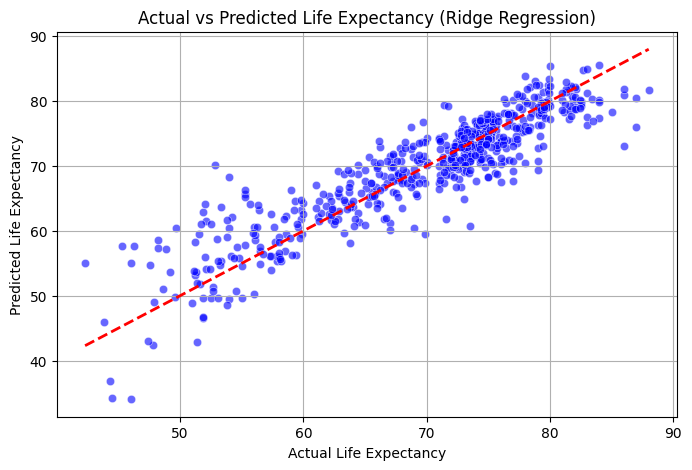

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Actual vs Predicted values for Ridge Model
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred_ridge, alpha=0.6, color='blue')

# Ideal line where Actual = Predicted
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title('Actual vs Predicted Life Expectancy (Ridge Regression)')
plt.grid(True)
plt.show()